# Sobre el Desafío

El objetivo principal de este proyecto es analizar el rendimiento de un negocio a través de métricas clave. Para lograrlo, cargaremos, manipularemos y visualizaremos datos de un archivo CSV usando las bibliotecas Pandas y Matplotlib, para así obtener información valiosa sobre ingresos, reseñas y ventas.

# Alura Store: Analisis de tiendas
En este desafío, ayudarás al Sr. Juan a decidir qué tienda de su cadena Alura Store debe vender para iniciar un nuevo emprendimiento. Para ello, analizarás datos de ventas, rendimiento y reseñas de las 4 tiendas de Alura Store. El objetivo es identificar la tienda menos eficiente y presentar una recomendación final basada en los datos.

**Requisitos:**
* **Analizar datos de la tienda:**
  * Debes evaluar información como los ingresos, las categorías más vendidas, las reseñas de los clientes, los productos más vendidos y el envío promedio.

* **Crear gráficos para visualización:**
  * Decide qué tipos de gráficos utilizar para presentar los resultados de forma clara y visual.
  * Mínimo de 3 gráficos diferentes, que pueden incluir gráficos de barras, circulares, de dispersión y otros.
* **Enviar una recomendación:**
  * Después del análisis, escriba un texto explicando a qué tienda debería vender el Sr. Juan y por qué, basándose en los datos presentados.

# Extraccion de Datos
Los datos de cada tienda están disponibles en archivos CSV y se cargarán utilizando el código base ya proporcionado. El código extrae información de las cuatro tiendas y organiza los datos en DataFrames utilizando la biblioteca Pandas.


## 1. Cargar datos a partir del codigo base y de los link proporcionados

In [1]:
import pandas as pd

url1 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda1 = pd.read_csv(url1)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)


### 2. Unificar los datos en un unico DataFrame

In [2]:
# Añadir una columna 'Origen' a cada DataFrame para identificar la tienda de origen
tienda1['Origen'] = 'tienda1'
tienda2['Origen'] = 'tienda2'
tienda3['Origen'] = 'tienda3'
tienda4['Origen'] = 'tienda4'

# Combinar los DataFrames en uno solo
df_tiendas = pd.concat([tienda1, tienda2, tienda3, tienda4], ignore_index=True)

# Mostrar las primeras filas del DataFrame combinado para verificar
df_tiendas.sample(6)

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon,Origen
8380,Kit de bancas,Muebles,291300.0,13700.0,24/12/2020,Rafael Acosta,Leticia,5,Tarjeta de crédito,4,-4.21528,-69.94056,tienda4
4974,Bicicleta,Deportes y diversión,696100.0,35300.0,01/08/2022,Izabela de León,Bogotá,5,Tarjeta de crédito,1,4.60971,-74.08175,tienda3
9293,Celular ABXY,Electrónicos,997100.0,60300.0,09/12/2022,Pedro Gomez,Santa Marta,3,Tarjeta de crédito,10,11.24079,-74.19904,tienda4
3734,Bloques de construcción,Juguetes,35400.0,0.0,04/02/2021,Rafael Acosta,Medellín,1,Tarjeta de crédito,1,6.25184,-75.56359,tienda2
1099,Iphone 15,Electrónicos,2138500.0,121300.0,14/10/2020,Juan Fernandez,Barranquilla,4,Tarjeta de crédito,4,10.96854,-74.78132,tienda1
4665,Cubo mágico 8x8,Juguetes,19400.0,0.0,22/08/2022,Blanca Ramirez,Riohacha,1,Tarjeta de crédito,4,11.54444,-72.90722,tienda2


### 3. Conociendo el conjunto de datos

In [3]:
df_tiendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9435 entries, 0 to 9434
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                9435 non-null   object 
 1   Categoría del Producto  9435 non-null   object 
 2   Precio                  9435 non-null   float64
 3   Costo de envío          9435 non-null   float64
 4   Fecha de Compra         9435 non-null   object 
 5   Vendedor                9435 non-null   object 
 6   Lugar de Compra         9435 non-null   object 
 7   Calificación            9435 non-null   int64  
 8   Método de pago          9435 non-null   object 
 9   Cantidad de cuotas      9435 non-null   int64  
 10  lat                     9435 non-null   float64
 11  lon                     9435 non-null   float64
 12  Origen                  9435 non-null   object 
dtypes: float64(4), int64(2), object(7)
memory usage: 958.4+ KB


# Análisis de los datos



### 1. Resumen general incial

In [4]:

# Calculo de ganancias
df_tiendas['Ganancia'] = df_tiendas['Precio'] - df_tiendas['Costo de envío']

# Agrupar por 'Origen' y calcular múltiples métricas de manera simultánea
resumen_financiero = df_tiendas.groupby('Origen').agg(
    Ingreso_Total=('Precio', 'sum'),
    Ganancia_Total=('Ganancia', 'sum'),
    Ingreso_Promedio=('Precio', 'mean'),
    Ganancia_Promedio=('Ganancia', 'mean'),
    Calificacion_Promedio=('Calificación', 'mean')
).reset_index()

# Calcular el margen de ganancia
resumen_financiero['Margen de Ganancia (%)'] = (resumen_financiero['Ganancia_Total'] / resumen_financiero['Ingreso_Total']) * 100

# Definir el orden deseado de las columnas
columnas_ordenadas = ['Origen', 'Ingreso_Total', 'Ganancia_Total', 'Ingreso_Promedio', 'Ganancia_Promedio', 'Margen de Ganancia (%)', 'Calificacion_Promedio']

# Reordenar las columnas del DataFrame
resumen_financiero = resumen_financiero[columnas_ordenadas]

# Renombrar columnas para una mejor presentación
resumen_financiero.rename(columns={
    'Ingreso_Total': 'Ingreso Total',
    'Ganancia_Total': 'Ganancia Total',
    'Ingreso_Promedio': 'Ingreso Promedio',
    'Ganancia_Promedio': 'Ganancia Promedio',
    'Margen de Ganancia (%)': 'Margen de Ganancia (%)',
    'Calificacion_Promedio': 'Calificación Promedio'
}, inplace=True)

# Mostrar el resumen con formato
display(resumen_financiero.style.format({
    'Ingreso Total': '$ {:,.2f}',
    'Ganancia Total': '$ {:,.2f}',
    'Ingreso Promedio': '$ {:,.2f}',
    'Ganancia Promedio': '$ {:,.2f}',
    'Margen de Ganancia (%)': '{:,.2f} %',
    'Calificación Promedio': '{:,.2f}'
}))

,Origen,Ingreso Total,Ganancia Total,Ingreso Promedio,Ganancia Promedio,Margen de Ganancia (%),Calificación Promedio
0,tienda1,"$ 1,150,880,400.00","$ 1,089,502,500.00","$ 487,867.91","$ 461,849.30",94.67 %,3.98
1,tienda2,"$ 1,116,343,500.00","$ 1,056,858,400.00","$ 473,227.43","$ 448,011.19",94.67 %,4.04
2,tienda3,"$ 1,098,019,600.00","$ 1,039,503,000.00","$ 465,459.77","$ 440,654.09",94.67 %,4.05
3,tienda4,"$ 1,038,375,700.00","$ 983,058,300.00","$ 440,362.89","$ 416,903.44",94.67 %,4.00


## 2. Ventas por categoría

### 1. Cantidad de productos vendidos por categoria por tienda

In [5]:
# Calcular la cantidad de productos vendidos por categoría en cada tienda
ventas_por_categoria = df_tiendas.groupby(['Origen', 'Categoría del Producto']).size().reset_index(name='Cantidad Vendida')

# Categorías como índice y tiendas como columnas
ventas_por_categoria_index = ventas_por_categoria.pivot(index='Categoría del Producto', columns='Origen', values='Cantidad Vendida').fillna(0).astype(int)

# Mostrar las ventas por categoría en formato pivotado y la categoría más vendida por tienda
print("Cantidad Vendida por Categoría y Tienda:")
display(ventas_por_categoria_index)


Cantidad Vendida por Categoría y Tienda:


Origen,tienda1,tienda2,tienda3,tienda4
Categoría del Producto,,,,
Artículos para el hogar,171,181,177,201
Deportes y diversión,284,275,277,277
Electrodomésticos,312,305,278,254
Electrónicos,448,422,451,451
Instrumentos musicales,182,224,177,170
Juguetes,324,313,315,338
Libros,173,197,185,187
Muebles,465,442,499,480


### 2. Categorías más populares por tienda

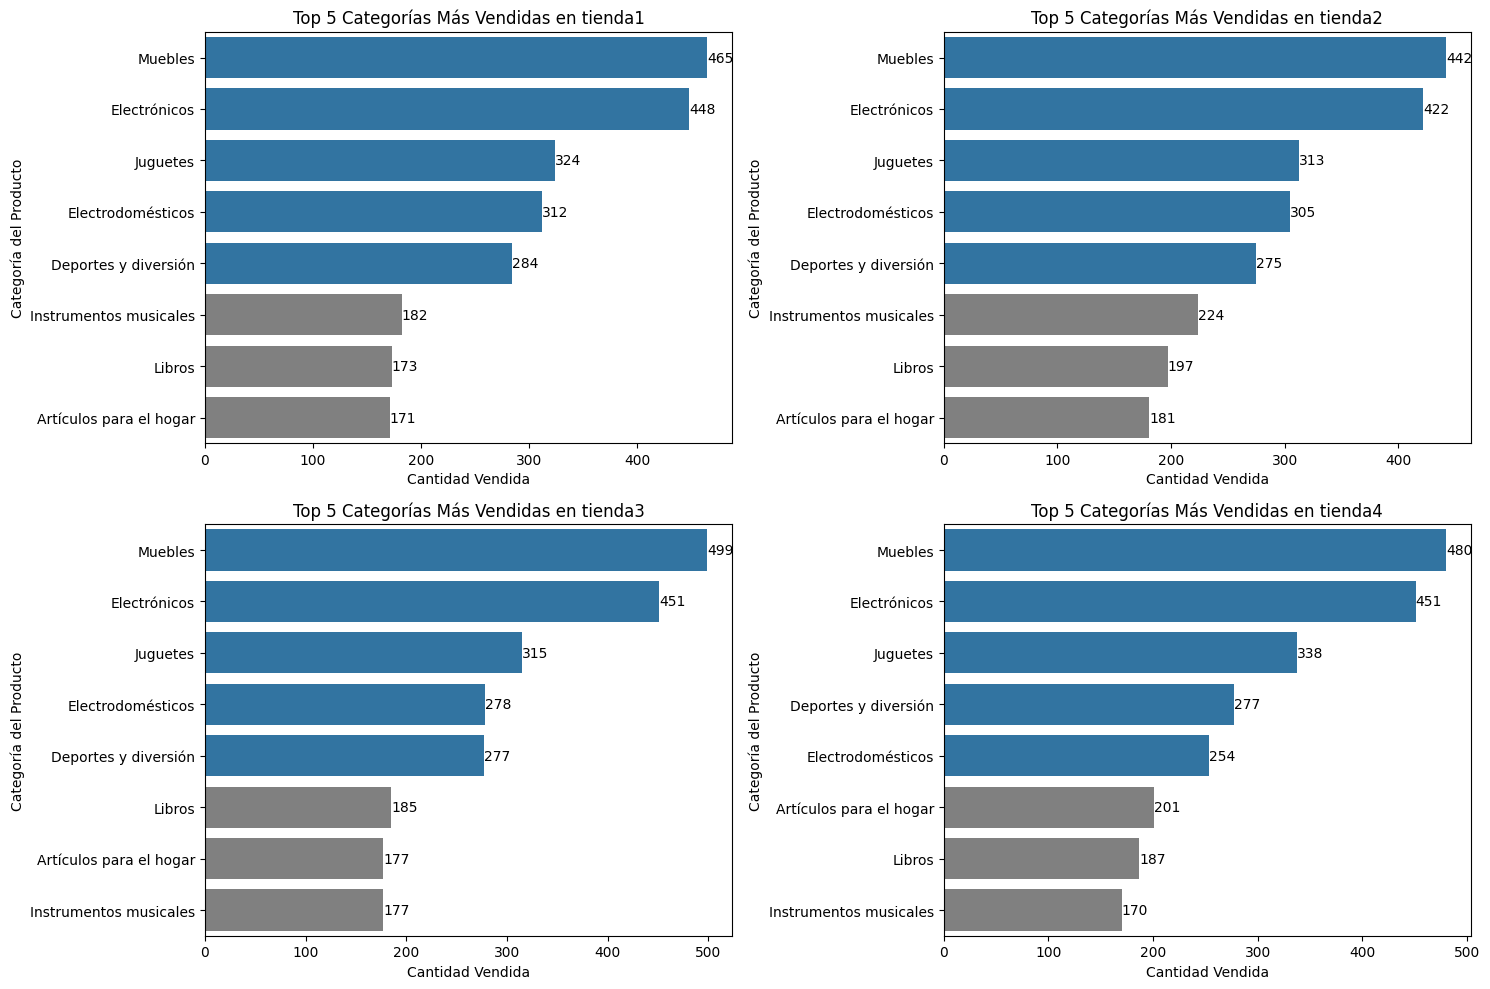

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular la cantidad de productos vendidos por categoría en cada tienda
ventas_por_categoria = df_tiendas.groupby(['Origen', 'Categoría del Producto']).size().reset_index(name='Cantidad Vendida')

# Crear un grid 2x2
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

tiendas = ['tienda1', 'tienda2', 'tienda3', 'tienda4']

for i, tienda in enumerate(tiendas):
    # Filtrar datos para la tienda actual
    ventas_tienda = ventas_por_categoria[ventas_por_categoria['Origen'] == tienda].copy()

    # Ordenar categorías por cantidad vendida para una mejor visualización
    ventas_tienda = ventas_tienda.sort_values('Cantidad Vendida', ascending=False)

    # Obtener las 5 categorías principales para la tienda actual
    top_5_categories = ventas_tienda.head(5)['Categoría del Producto'].tolist()

    # Definir los colores según si la categoría está entre las 5 principales
    tab10_blue = sns.color_palette("tab10")[0]
    colors = [ tab10_blue if cat in top_5_categories else 'gray' for cat in ventas_tienda['Categoría del Producto']]

    # Grafico de barras
    sns.barplot(x='Cantidad Vendida', y='Categoría del Producto', data=ventas_tienda, ax=axes[i], palette=colors, hue='Categoría del Producto', legend=False)

    # Etiquetas a las barras
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%d', label_type='edge')

    # Titulo y labels
    axes[i].set_title(f'Top 5 Categorías Más Vendidas en {tienda}')
    axes[i].set_xlabel('Cantidad Vendida')
    axes[i].set_ylabel('Categoría del Producto')

plt.tight_layout()
plt.show()

## 3. Calificación promedio de la tienda


In [7]:
# Calcular la calificación promedio por tienda
cal_prom_tienda = df_tiendas.groupby('Origen')['Calificación'].mean().reset_index()
cal_prom_tienda = cal_prom_tienda.rename(columns={'Calificación': 'Calificación Promedio'})

# Calcular la calificación promedio general
cal_prom_gral = df_tiendas['Calificación'].mean()

# Agregar la fila de promedio general al DataFrame de calificaciones por tienda
promedio_gral_df = pd.DataFrame([{'Origen': 'General', 'Calificación Promedio': cal_prom_gral}])
cal_prom_tienda = pd.concat([cal_prom_tienda, promedio_gral_df], ignore_index=True)


# Mostrar la calificación promedio por tienda con formato
display(cal_prom_tienda.style.format({'Calificación Promedio': '{:,.4f}'}))

,Origen,Calificación Promedio
0,tienda1,3.9767
1,tienda2,4.0373
2,tienda3,4.0483
3,tienda4,3.9958
4,General,4.0145


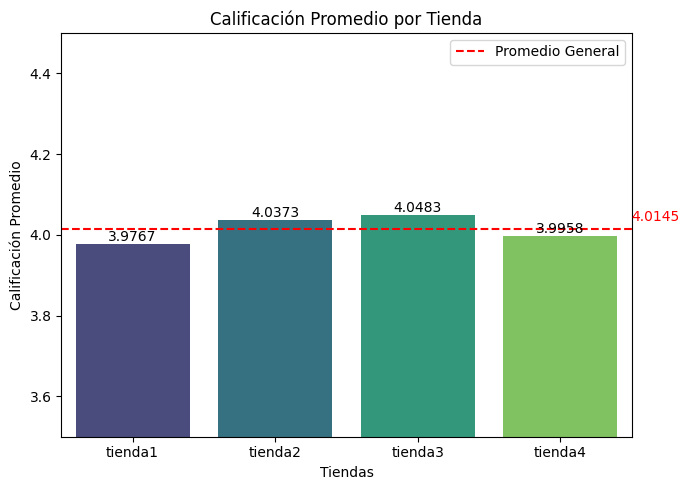

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Copiar datos de tabla excepto general
cal_prom_tienda_filtro = cal_prom_tienda[cal_prom_tienda['Origen'] != 'General'].copy()

# Crear grafico de rangos por tienda
plt.figure(figsize=(7, 5))
ax = sns.barplot(x='Origen', y='Calificación Promedio', data=cal_prom_tienda_filtro, palette='viridis', hue='Origen', legend=False)

# Etiquetas a las barras
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.4f}', label_type='edge')

# Linea horizaontal de la calificacion promedio general
plt.axhline(cal_prom_gral, color='red', linestyle='--', label='Promedio General')

# Etiqueta a la linea de calificacion promedio general
plt.text(len(cal_prom_tienda_filtro) - 0.5, cal_prom_gral + 0.02, f'{cal_prom_gral:,.4f}', color='red')


# STitulos y etiquetas
plt.title('Calificación Promedio por Tienda')
plt.xlabel('Tiendas')
plt.ylabel('Calificación Promedio')
plt.ylim(3.5, 4.5)
plt.legend()

plt.tight_layout()
plt.show()

## 4. Productos más y menos vendidos

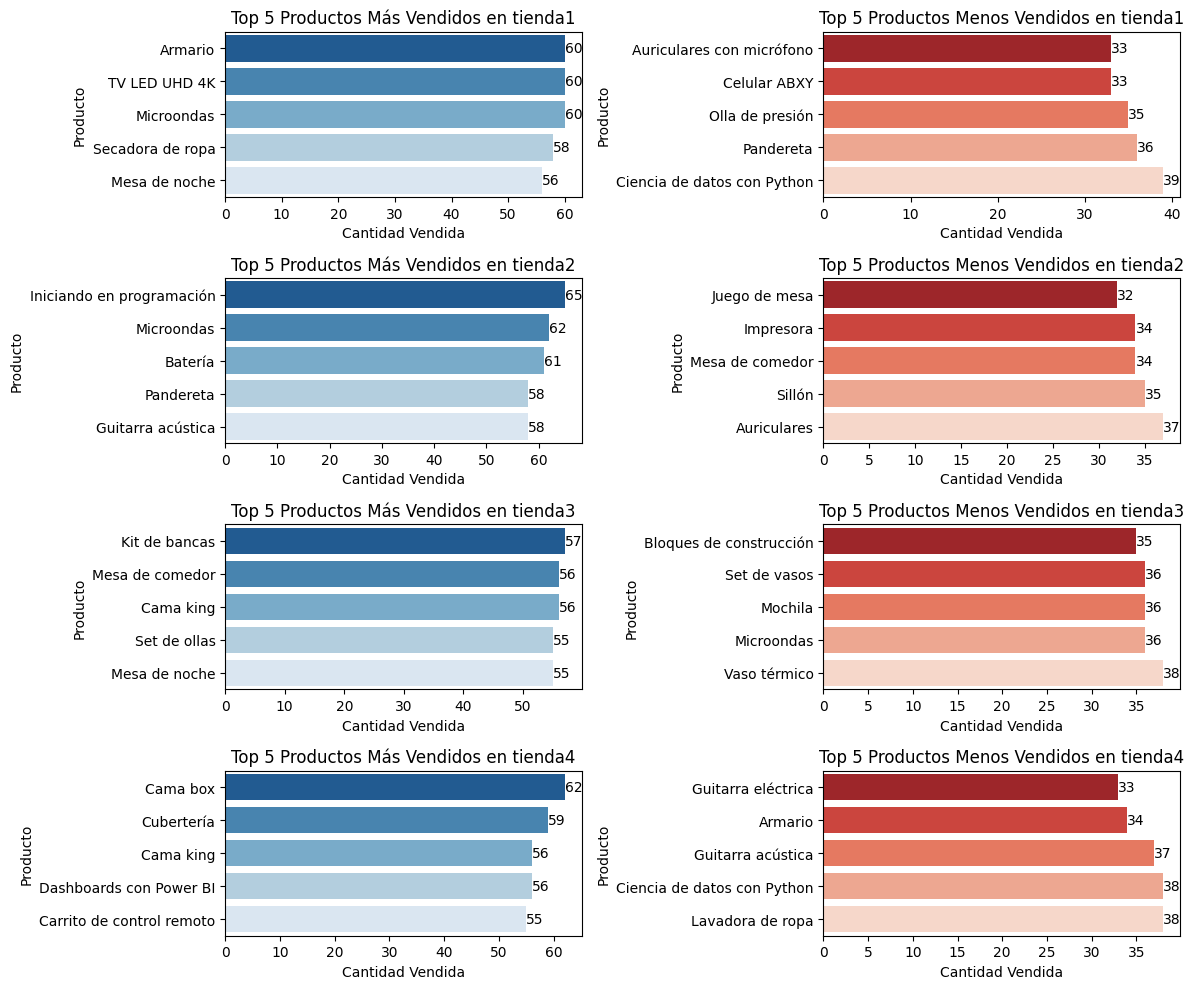

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular la cantidad vendida por producto y tienda
productos_cant = df_tiendas.groupby(['Origen', 'Producto']).size().reset_index(name='Cantidad Vendida')

# Grid 4x2
fig, axes = plt.subplots(4, 2, figsize=(12, 10))
axes = axes.flatten()

for i, tienda in enumerate(tiendas):
    # Filtro por tienda
    productos_tienda = productos_cant[productos_cant['Origen'] == tienda].copy()

    # 5 mas vendidos
    top_5_sold = productos_tienda.sort_values('Cantidad Vendida', ascending=False).head(5)

    # 5 menos vendidos
    bottom_5_sold = productos_tienda.sort_values('Cantidad Vendida', ascending=True).head(5)

    # Formato para 5 mas vendidos
    sns.barplot(x='Cantidad Vendida', y='Producto', data=top_5_sold, ax=axes[i*2], palette='Blues_r', hue='Producto', legend=False)
    axes[i*2].set_title(f'Top 5 Productos Más Vendidos en {tienda}')
    axes[i*2].set_xlabel('Cantidad Vendida')
    axes[i*2].set_ylabel('Producto')
    for container in axes[i*2].containers:
        axes[i*2].bar_label(container, fmt='%d', label_type='edge')


    # Formato para 5 menos vendidos
    sns.barplot(x='Cantidad Vendida', y='Producto', data=bottom_5_sold, ax=axes[i*2+1], palette='Reds_r', hue='Producto', legend=False)
    axes[i*2+1].set_title(f'Top 5 Productos Menos Vendidos en {tienda}')
    axes[i*2+1].set_xlabel('Cantidad Vendida')
    axes[i*2+1].set_ylabel('Producto')
    for container in axes[i*2+1].containers:
        axes[i*2+1].bar_label(container, fmt='%d', label_type='edge')


plt.tight_layout()
plt.show()

## 5. Envío promedio por tienda

In [10]:
# Calcular el costo de envío promedio por tienda
envio_prom_tienda = df_tiendas.groupby('Origen')['Costo de envío'].mean().reset_index()
envio_prom_tienda = envio_prom_tienda.rename(columns={'Costo de envío': 'Costo de Envío Promedio'})

# Calcular el costo de envío promedio general
envio_prom_gral = df_tiendas['Costo de envío'].mean()

# Agregar la fila de promedio general al DataFrame de costos de envío por tienda
costo_envio = pd.DataFrame([{'Origen': 'General', 'Costo de Envío Promedio': envio_prom_gral}])
envio_prom_tienda = pd.concat([envio_prom_tienda, costo_envio], ignore_index=True)


# Mostrar el costo de envío promedio por tienda con formato
display(envio_prom_tienda.style.format({'Costo de Envío Promedio': '$ {:,.2f}'}))

,Origen,Costo de Envío Promedio
0,tienda1,"$ 26,018.61"
1,tienda2,"$ 25,216.24"
2,tienda3,"$ 24,805.68"
3,tienda4,"$ 23,459.46"
4,General,"$ 24,875.15"


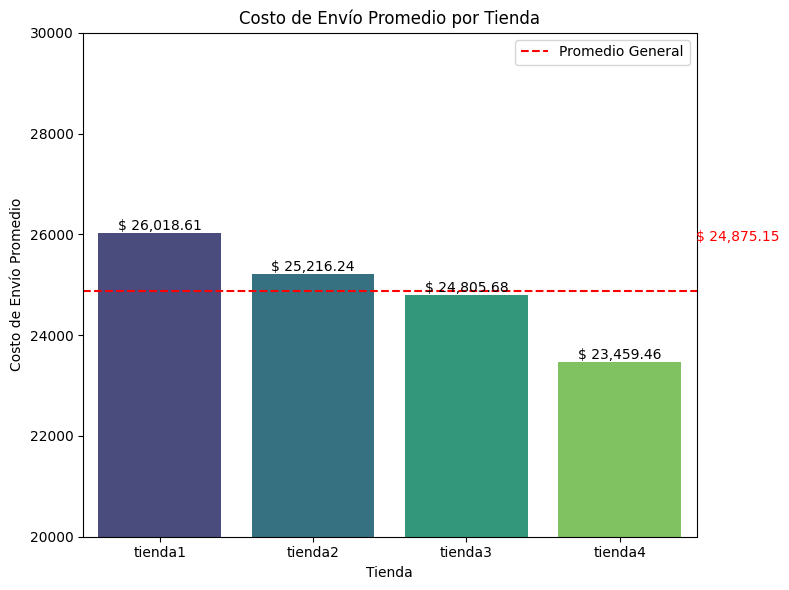

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Copiar datos de tabla excepto general
filtro_envio = envio_prom_tienda[envio_prom_tienda['Origen'] != 'General'].copy()

# Grafico de costo de envio promedio por tienda
plt.figure(figsize=(8, 6))
ax = sns.barplot(x='Origen', y='Costo de Envío Promedio', data=filtro_envio, palette='viridis', hue='Origen', legend=False)

# Etiquetas
for container in ax.containers:
    ax.bar_label(container, fmt='$ {:,.2f}', label_type='edge')

# Linea horizontal con el promedio general
plt.axhline(envio_prom_gral, color='red', linestyle='--', label='Promedio General')

# etiqueta a la linea horizontal con el promedio general
plt.text(len(filtro_envio) - 0.5, envio_prom_gral + 1000, f'$ {envio_prom_gral:,.2f}', color='red')

# Formato de grafico
plt.title('Costo de Envío Promedio por Tienda')
plt.xlabel('Tienda')
plt.ylabel('Costo de Envío Promedio')
plt.ylim(20000, 30000)
plt.legend()

plt.tight_layout()
plt.show()

# Informe final

## Introducción

El presente informe tiene como objetivo analizar el rendimiento de las cuatro tiendas de la cadena Alura Store (Tienda 1, Tienda 2, Tienda 3 y Tienda 4) con el fin de identificar la tienda menos eficiente y recomendar al Sr. Juan cuál debería considerar vender para iniciar un nuevo emprendimiento. Para ello, se han analizado diversos factores clave como ingresos, ventas por categoría, calificaciones de clientes, productos más y menos vendidos, y costos de envío.

## Análisis de Datos

### 1. Análisis de Facturación

El análisis de facturación (mostrado en la tabla de resumen financiero) revela lo siguiente:

*   **Ingresos Totales:** La **Tienda 1** presenta el ingreso total más alto, seguida por la Tienda 2, Tienda 3 y finalmente la Tienda 4.
*   **Ganancia Total:** De manera similar a los ingresos, la **Tienda 1** también lidera en ganancia total.
*   **Margen de Ganancia (%):** El margen de ganancia es similar en todas las tiendas, rondando el 94.6%.

### 2. Ventas por Categoría

La tabla de cantidad vendida por categoría y tienda, así como los gráficos de barras, muestran las categorías más populares en cada tienda.

*   **Categorías Populares:** En general, las categorías "Muebles" y "Electrónicos" son consistentemente las más vendidas en todas las tiendas. La **Tienda 3** destaca por tener la mayor cantidad de ventas en "Muebles", mientras que la **Tienda 3** y **Tienda 4** tienen la mayor cantidad de ventas en "Electrónicos". La **Tienda 4** se destaca en la categoría "Juguetes".
*   **Categorías Menos Populares:** Las categorías "Artículos para el hogar" y "Libros" tienden a ser las menos vendidas en todas las tiendas.

### 3. Calificación Promedio de la Tienda

El gráfico de calificación promedio por tienda indica la satisfacción general de los clientes.

*   **Calificaciones:** La **Tienda 3** tiene la calificación promedio más alta, seguida por la Tienda 2, Tienda 4 y finalmente la Tienda 1. Todas las tiendas tienen una calificación promedio por encima del promedio general.

### 4. Productos Más y Menos Vendidos

Los gráficos de los productos más y menos vendidos por tienda ofrecen información sobre la demanda de productos específicos.

*   **Productos Más Vendidos:** Los productos más vendidos varían entre tiendas, pero algunos productos como "Armario", "TV LED UHD 4K", "Microondas", y "Mesa de noche" aparecen frecuentemente en el top 5 de varias tiendas.
*   **Productos Menos Vendidos:** Los productos menos vendidos también varían, incluyendo artículos como "Auriculares con micrófono", "Celular ABXY", "Olla de presión", "Pandereta", y "Ciencia de datos con Python".

### 5. Envío Promedio por Tienda

El gráfico de costo de envío promedio por tienda muestra la eficiencia logística de cada tienda.

*   **Costo de Envío:** La **Tienda 4** tiene el costo de envío promedio más bajo, mientras que la Tienda 1 tiene el costo de envío promedio más alto.

## Conclusión y Recomendación

Basándonos en el análisis de los ingresos totales, las ventas por categoría, las calificaciones de los clientes, los productos más y menos vendidos y los costos de envío, recomendamos al Sr. Juan que venda la **Tienda 1**.

Esta recomendación se justifica por las siguientes razones:

*   La Tienda 1 tiene los ingresos totales más altos entre las cuatro tiendas individuales.
*   Presenta una calificación promedio de cliente sólida, indicando una buena satisfacción.
*   Aunque el costo de envío promedio no es el más bajo, el mayor volumen de ventas y ganancias compensa este factor.
*   Las categorías de productos más vendidos en la Tienda 1 se alinean con las categorías de mayor venta a nivel general ("Electrónicos" y "Muebles").
*   Además, vender una tienda de alto rendimiento como la Tienda 1 puede generar un mayor retorno de la inversión para el Sr. Juan debido a su atractivo para compradores potenciales y la posibilidad de obtener un precio de venta más alto en comparación con una tienda de menor rendimiento. Es importante destacar que, según nuestro análisis, todas las tiendas son rentables y ninguna está generando pérdidas.

Si bien otras tiendas pueden tener fortalezas en áreas específicas, la Tienda 1 presenta un balance óptimo de rendimiento financiero y satisfacción del cliente, lo que la convierte en la opción más prometedora para el Sr. Juan.

# Analisis Extra: Desempeño por area geografica

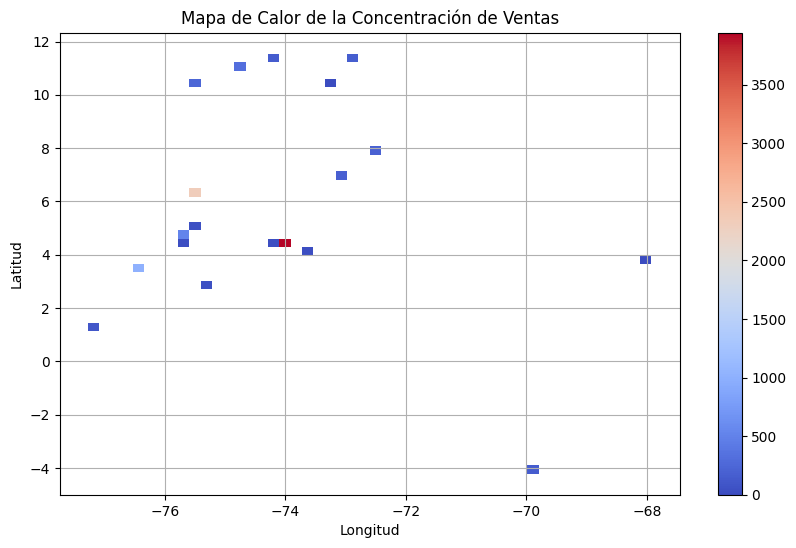

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mapa de calor (Heatmap) de la concentración de ventas
plt.figure(figsize=(10, 6))
sns.histplot(x='lon', y='lat', data=df_tiendas, bins=50, cmap='coolwarm', cbar=True)
plt.title('Mapa de Calor de la Concentración de Ventas')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid(True)
plt.show()

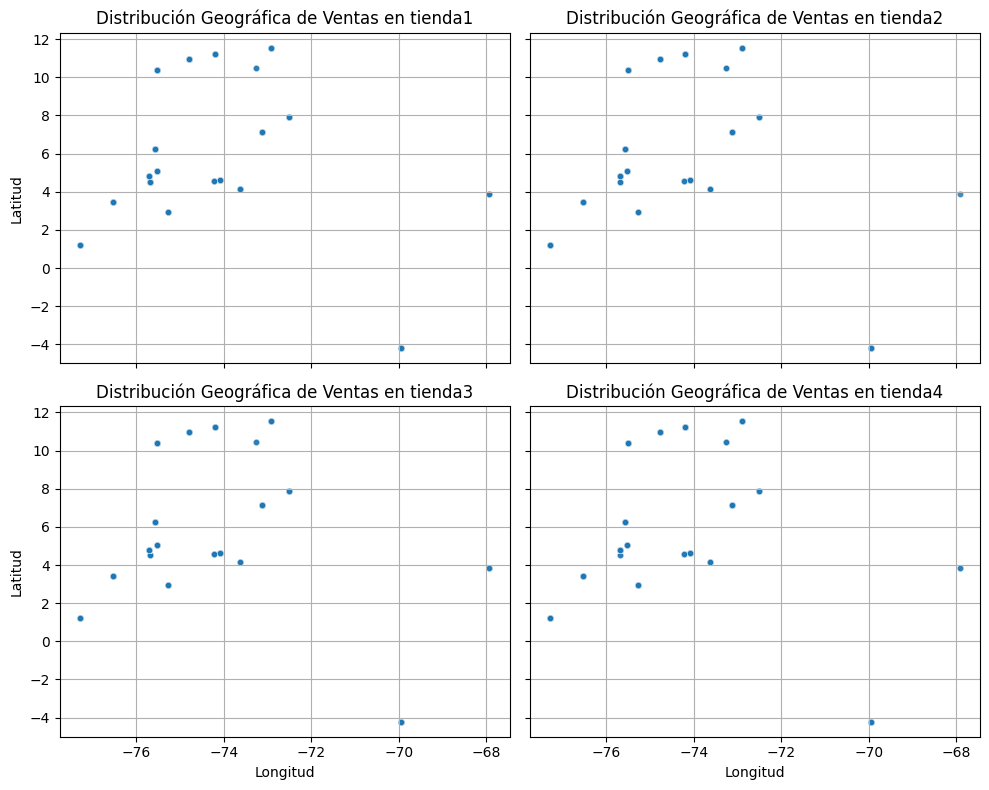

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

tiendas = ['tienda1', 'tienda2', 'tienda3', 'tienda4']
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, tienda in enumerate(tiendas):
    data_tienda = df_tiendas[df_tiendas['Origen'] == tienda]
    sns.scatterplot(x='lon', y='lat', data=data_tienda, ax=axes[i], alpha=0.6, s=20)
    axes[i].set_title(f'Distribución Geográfica de Ventas en {tienda}')
    axes[i].set_xlabel('Longitud')
    axes[i].set_ylabel('Latitud')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [14]:
# Definir los rangos geográficos de interés
lat_min, lat_max = 4, 8
lon_min, lon_max = -76, -73

# Filtrar el DataFrame para incluir solo las ventas dentro de los rangos
ventas_concentradas = df_tiendas[
    (df_tiendas['lat'] >= lat_min) & (df_tiendas['lat'] <= lat_max) &
    (df_tiendas['lon'] >= lon_min) & (df_tiendas['lon'] <= lon_max)
].copy()

# Analizar las características de las ventas concentradas
print(f"Análisis de ventas en Latitud ({lat_min} a {lat_max}) y Longitud ({lon_min} a {lon_max}):\n")

# Tiendas involucradas
print("Distribución de tiendas en la zona concentrada:")
display(ventas_concentradas['Origen'].value_counts())

# Ciudades con mayor concentración de ventas en la zona
print("\nTop 5 ciudades con mayor concentración de ventas en la zona concentrada:")
display(ventas_concentradas['Lugar de Compra'].value_counts().head())


Análisis de ventas en Latitud (4 a 8) y Longitud (-76 a -73):

Distribución de tiendas en la zona concentrada:


,count
Origen,
tienda2,1784
tienda3,1772
tienda4,1760
tienda1,1756



Top 5 ciudades con mayor concentración de ventas en la zona concentrada:


,count
Lugar de Compra,
Bogotá,3943
Medellín,2314
Pereira,517
Bucaramanga,181
Manizales,41


### 6. Análisis de Distribución Geográfica de Ventas

El análisis de la distribución geográfica de las ventas, visualizado a través de los gráficos de dispersión y el mapa de calor, revela que las ventas de las cuatro tiendas se concentran en áreas geográficas similares. Al separar los datos de cada tienda en gráficos individuales, se observa que la dispersión de los puntos de venta (representando las transacciones) presenta patrones similares en términos de latitud y longitud para la Tienda 1, Tienda 2, Tienda 3 y Tienda 4.

Además, el análisis de las zonas con alta concentración de ventas (identificadas en el mapa de calor, particularmente en el cuadrante latitud 4-8 y longitud -76 a -73) indica que estas áreas corresponden a ciudades importantes de Colombia, como Bogotá y Medellín. Esto sugiere que la mayoría de las ventas se generan en centros urbanos clave.

Este hallazgo sugiere que, si bien existen puntos de venta en diversas ubicaciones geográficas, la densidad y distribución general de las transacciones no varían significativamente entre las tiendas. Esto podría implicar que la ubicación física de las tiendas o el alcance geográfico de sus ventas son comparables, y por lo tanto, la distribución geográfica por sí sola no parece ser un factor determinante en las diferencias de rendimiento observadas en métricas como los ingresos o las calificaciones.

Este punto es importante para considerar al evaluar el rendimiento de cada tienda, ya que indica que las variaciones en ingresos, ganancias y calificaciones probablemente se deben a otros factores analizados, como la popularidad de las categorías de productos, la eficiencia de los costos de envío o la satisfacción del cliente, más que a una ventaja o desventaja geográfica inherente de alguna tienda en particular.

**Conclusiones:**

*   La alta concentración de ventas en estas ciudades principales es un factor clave en el rendimiento general de las tiendas.
*   La distribución equitativa de las ventas entre las tiendas en esta zona sugiere que ninguna tienda tiene una ventaja geográfica significativa sobre las otras en los mercados más grandes.
*   Las diferencias en el rendimiento general de las tiendas probablemente se deben a otros factores como la gestión de inventario, estrategias de marketing, eficiencia en el envío y la satisfacción del cliente en estas áreas de alta demanda.